# MBTI Text Classification - Exploratory Data Analysis

This notebook analyzes the MBTI text dataset to understand label distribution, text characteristics, vocabulary patterns, and modeling risks before training classifiers.

| Attribute | Detail |
|-----------|--------|
| Records | 8,675 user-level text records |
| Raw Columns | `type`, `posts` |
| Target | `type` (16 MBTI classes) |
| Data Quality | Missing values and duplicates audited in Section 1.1 |

### EDA Flow
1. **Data Import and Inspection** - load data, inspect schema, and sample records.
2. **Data Quality Checks** - missing values and duplicate analysis.
3. **Feature Engineering and Cleaning** - create text/meta features and cleaned text variants.
4. **Distribution and Lexical Analysis** - labels, traits, length metrics, top terms, and n-grams.
5. **Similarity and Summary Statistics** - TF-IDF similarity and aggregate text metrics.
6. **Findings and Risks** - summarize key observations and preprocessing recommendations.

In [24]:
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from nltk.corpus import stopwords
import ssl
import certifi
import nltk

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
nltk.download("stopwords")

sns.set_theme(style="whitegrid", context="notebook")

CHART_COLORS = {
    "primary": "#2563EB",
    "secondary": "#0EA5E9",
    "accent": "#14B8A6",
    "neutral": "#334155",
    "background": "#F8FAFC",
}


def style_ax(ax, title, xlabel=None, ylabel=None):
    ax.set_title(title, loc="left", fontsize=13, fontweight="bold", color=CHART_COLORS["neutral"], pad=10)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.set_facecolor(CHART_COLORS["background"])
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)

[nltk_data] Downloading package stopwords to /Users/mac/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Dataset Overview

Inspect the dataset shape, schema, and representative sample rows before any transformation.

In [6]:
DATA_PATH = "../../../datasets/mbti/data/mbti_1.csv"
df = pd.read_csv(DATA_PATH)
df.shape

(8675, 2)

In [3]:
df.head()

,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8675 entries, 0 to 8674
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   type    8675 non-null   str  
 1   posts   8675 non-null   str  
dtypes: str(2)
memory usage: 135.7 KB


In [5]:
df["type"].value_counts()

type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64

In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nSample data:")
display(df.head())

Shape: (8675, 2)

Columns:
Index(['type', 'posts'], dtype='str')

Data types:
type     str
posts    str
dtype: object

Sample data:


,type,posts
0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,ENTP,'I'm finding the lack of me in these posts ver...
2,INTP,'Good one _____ https://www.youtube.com/wat...
3,INTJ,"'Dear INTP, I enjoyed our conversation the o..."
4,ENTJ,'You're fired.|||That's another silly misconce...


### 1.1 Data Quality Checks (Missing Values and Duplicates)

In [3]:
missing_report = df.isna().sum().rename("missing_count").to_frame()
missing_report["missing_pct"] = (missing_report["missing_count"] / len(df) * 100).round(2)

duplicate_row_count = int(df.duplicated().sum())
duplicate_posts_count = int(df.duplicated(subset=["posts"]).sum())
duplicate_type_posts_count = int(df.duplicated(subset=["type", "posts"]).sum())

print("Missing value report:")
display(missing_report)

duplicate_summary = pd.DataFrame(
    {
        "metric": [
            "Duplicate full rows",
            "Duplicate posts only",
            "Duplicate (type, posts) pairs",
        ],
        "value": [
            duplicate_row_count,
            duplicate_posts_count,
            duplicate_type_posts_count,
        ],
    }
)

print("\nDuplicate report:")
display(duplicate_summary)

Missing value report:


,missing_count,missing_pct
type,0,0.0
posts,0,0.0



Duplicate report:


,metric,value
0,Duplicate full rows,0
1,Duplicate posts only,0
2,"Duplicate (type, posts) pairs",0


## 2. Feature Engineering

In [7]:
df["posts"] = df["posts"].astype(str)

df["word_count"] = df["posts"].apply(lambda x: len(x.split()))
df["char_count"] = df["posts"].apply(len)
df["num_posts"] = df["posts"].apply(lambda x: len(x.split("|||")))

df["I_E"] = df["type"].str[0]
df["N_S"] = df["type"].str[1]
df["T_F"] = df["type"].str[2]
df["J_P"] = df["type"].str[3]

## 3. Text Cleaning

In [8]:
STOP_WORDS = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)
    text = text.replace("|||", " ")
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text

def remove_stopwords(text):
    return " ".join(
        [w for w in text.split() if w not in STOP_WORDS and len(w) > 2]
    )

df["clean"] = df["posts"].apply(clean_text)
df["clean_ns"] = df["clean"].apply(remove_stopwords)

### 3.1 Label Leakage Check (MBTI Tokens in Text)

Check whether MBTI labels (e.g., `infj`, `intp`) appear directly in posts. If this leakage is high, models can overfit by memorizing label words rather than learning language patterns.

In [17]:
mbti_tokens = [
    "infj", "infp", "intj", "intp", "isfj", "isfp", "istj", "istp",
    "enfj", "enfp", "entj", "entp", "esfj", "esfp", "estj", "estp",
]

for token in mbti_tokens:
    df[f"has_{token}"] = df["clean"].str.contains(rf"\b{token}\b", regex=True)

leak_by_type = []
for mbti_type in sorted(df["type"].unique()):
    token = mbti_type.lower()
    rate = df.loc[df["type"] == mbti_type, f"has_{token}"].mean()
    leak_by_type.append({"type": mbti_type, "self_token_leak_rate": round(float(rate), 4)})

leak_df = pd.DataFrame(leak_by_type).sort_values("self_token_leak_rate", ascending=False)

display(leak_df)
print(f"Average self-token leakage rate: {leak_df['self_token_leak_rate'].mean():.4f}")

,type,self_token_leak_rate
1,ENFP,0.9022
7,ESTP,0.8989
12,ISFJ,0.8976
3,ENTP,0.8920
0,ENFJ,0.8842
10,INTJ,0.8836
15,ISTP,0.8754
9,INFP,0.8684
8,INFJ,0.8667
14,ISTJ,0.8634


Average self-token leakage rate: 0.8536


### 3.2 Leakage Mitigation for Analysis

Create a no-leak text version by removing MBTI tokens from cleaned text.

In [18]:
mbti_pattern = r"\b(?:" + "|".join(mbti_tokens) + r")\b"
df["clean_ns_noleak"] = (
    df["clean_ns"]
    .str.replace(mbti_pattern, " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

empty_after_clean = int((df["clean_ns_noleak"].str.len() == 0).sum())
print(f"Rows with empty text after MBTI-token removal: {empty_after_clean:,}")
display(df[["type", "clean_ns", "clean_ns_noleak"]].sample(5, random_state=42))

Rows with empty text after MBTI-token removal: 1


,type,clean_ns,clean_ns_noleak
2802,INTP,lie avoid unreasonable response something comp...,lie avoid unreasonable response something comp...
2166,INTJ,said zero flexibility little time dating going...,said zero flexibility little time dating going...
1919,INTP,written bias something sure could even say tru...,written bias something sure could even say tru...
360,ENFP,hauhuhauh might right muhicz wondering steps c...,hauhuhauh might right muhicz wondering steps c...
1115,ENTJ,parents kind college good job people want stab...,parents kind college good job people want stab...


## 4. MBTI Label Distribution

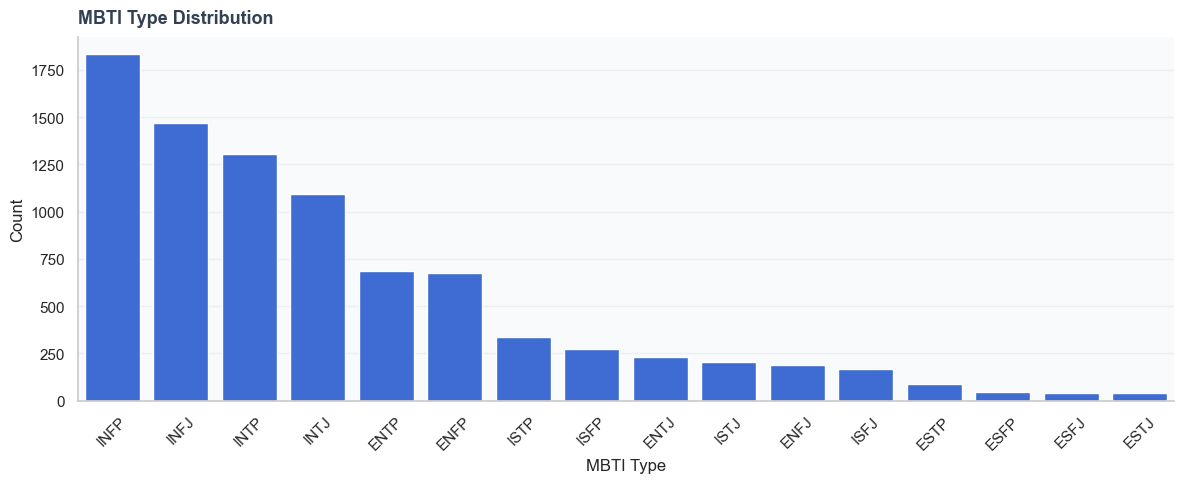

In [25]:
type_order = df["type"].value_counts().index

fig, ax = plt.subplots(figsize=(12, 5))
sns.countplot(data=df, x="type", order=type_order, color=CHART_COLORS["primary"], ax=ax)
style_ax(ax, "MBTI Type Distribution", "MBTI Type", "Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 5. Trait Distribution

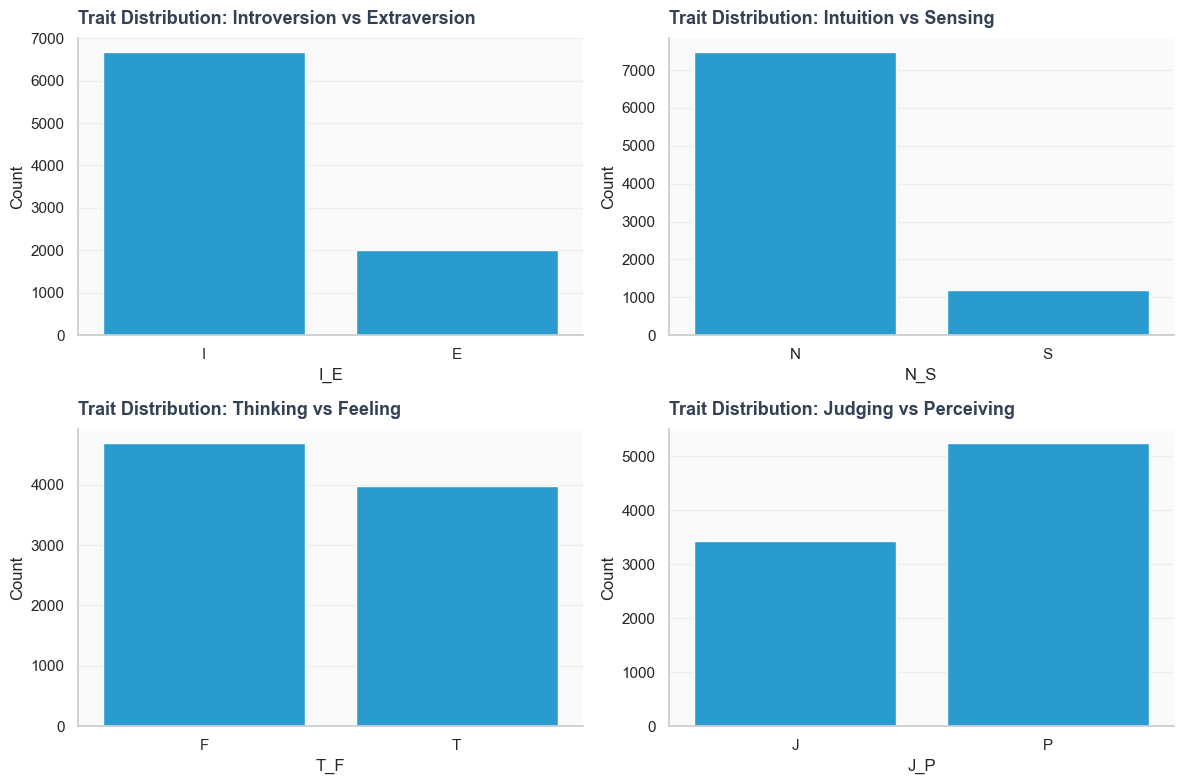

In [26]:
traits = ["I_E", "N_S", "T_F", "J_P"]
trait_titles = {
    "I_E": "Trait Distribution: Introversion vs Extraversion",
    "N_S": "Trait Distribution: Intuition vs Sensing",
    "T_F": "Trait Distribution: Thinking vs Feeling",
    "J_P": "Trait Distribution: Judging vs Perceiving",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, t in zip(axes.flatten(), traits):
    sns.countplot(data=df, x=t, color=CHART_COLORS["secondary"], ax=ax)
    style_ax(ax, trait_titles[t], t, "Count")

plt.tight_layout()
plt.show()

## 6. Word Count Distribution

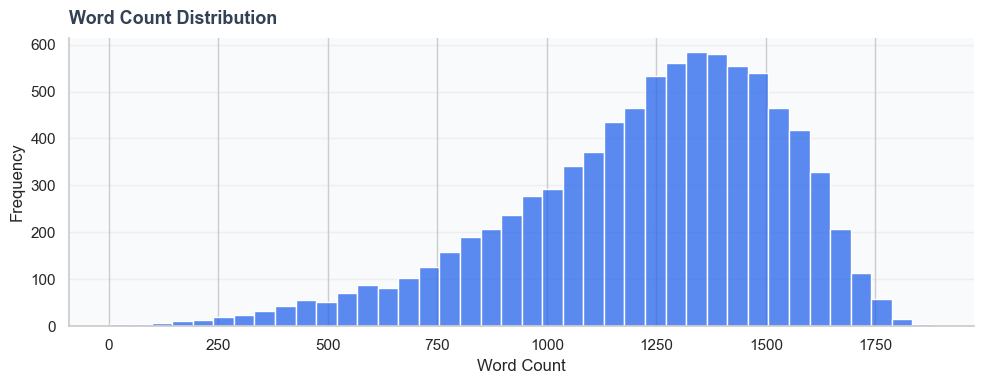

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["word_count"], bins=40, color=CHART_COLORS["primary"], edgecolor="white", ax=ax)
style_ax(ax, "Word Count Distribution", "Word Count", "Frequency")
plt.tight_layout()
plt.show()

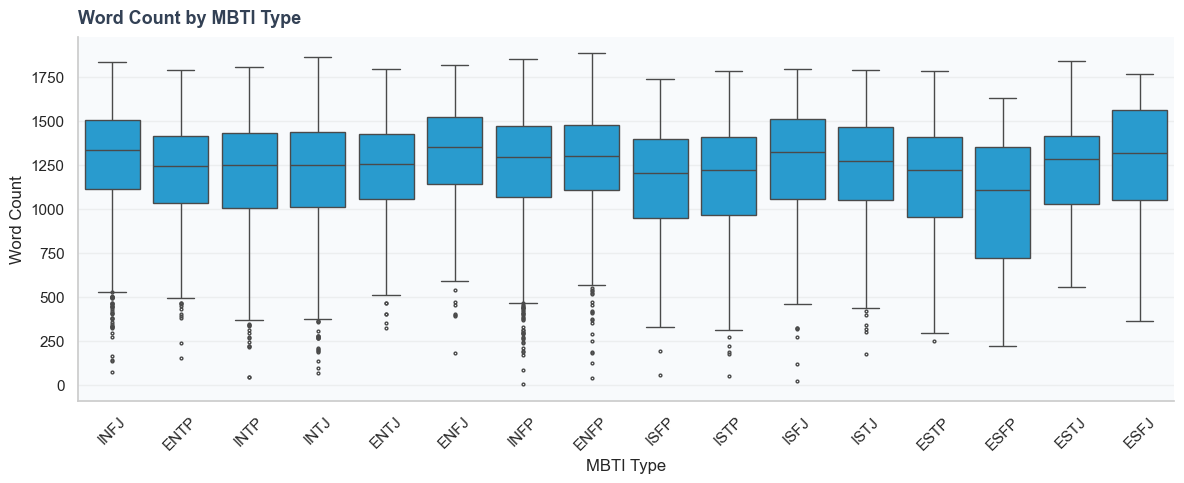

In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="type", y="word_count", color=CHART_COLORS["secondary"], fliersize=2, ax=ax)
style_ax(ax, "Word Count by MBTI Type", "MBTI Type", "Word Count")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 7. Character Count Distribution

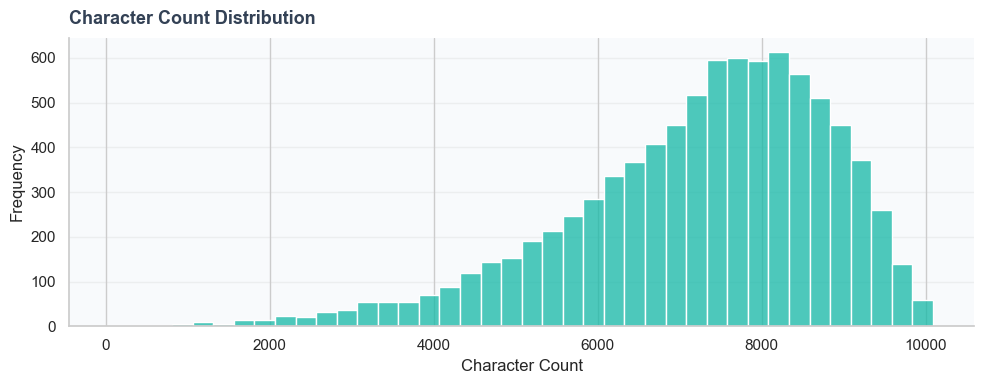

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["char_count"], bins=40, color=CHART_COLORS["accent"], edgecolor="white", ax=ax)
style_ax(ax, "Character Count Distribution", "Character Count", "Frequency")
plt.tight_layout()
plt.show()

## 8. Number of Posts per User

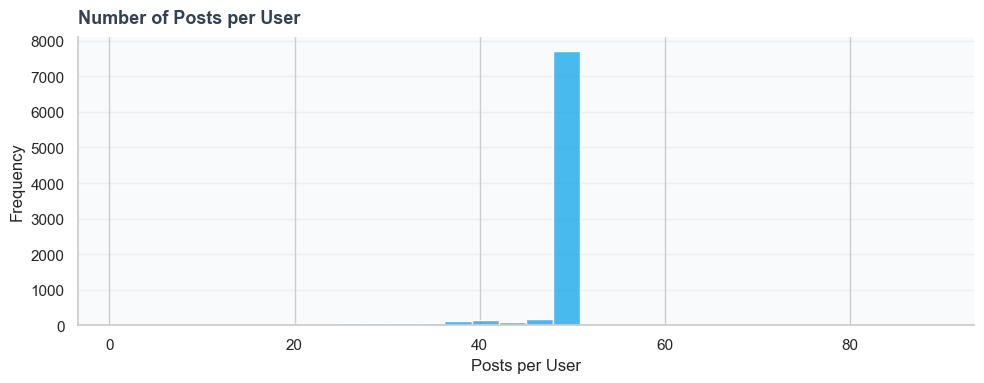

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(df["num_posts"], bins=30, color=CHART_COLORS["secondary"], edgecolor="white", ax=ax)
style_ax(ax, "Number of Posts per User", "Posts per User", "Frequency")
plt.tight_layout()
plt.show()

## 9. Stopword Analysis

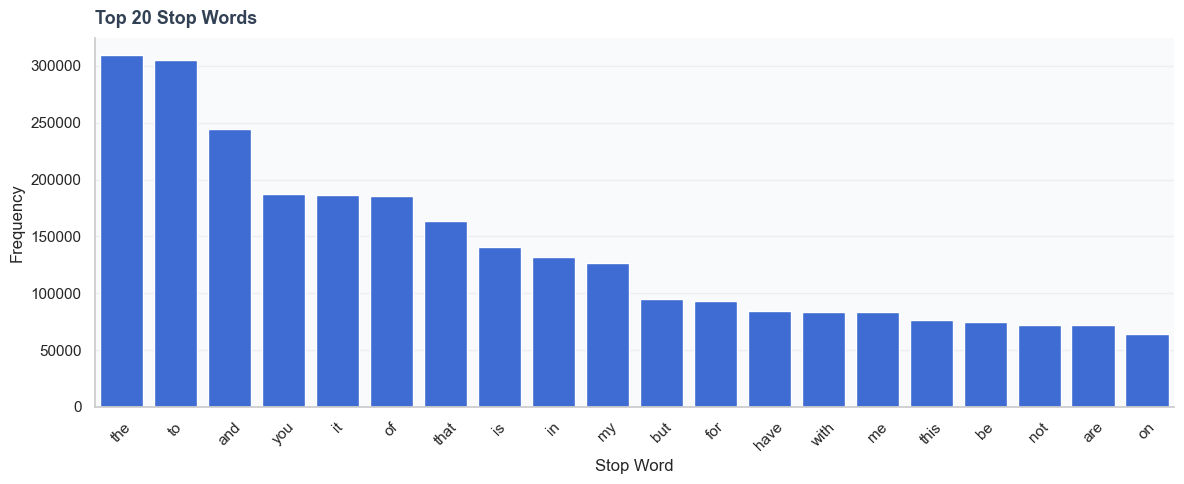

Total words (len>1): 10,096,772
Total stop words: 4,891,697 (48.45%)


,word,count
0,the,309206
1,to,305359
2,and,244085
3,you,187528
4,it,186192
5,of,185863
6,that,163538
7,is,140597
8,in,131618
9,my,126546


In [31]:
tokens = [t for t in " ".join(df["clean"]).split() if len(t) > 1]
stop_tokens = [t for t in tokens if t in STOP_WORDS]
stop_counts = Counter(stop_tokens).most_common(20)

stop_df = pd.DataFrame(stop_counts, columns=["word", "count"])

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=stop_df, x="word", y="count", color=CHART_COLORS["primary"], ax=ax)
style_ax(ax, "Top 20 Stop Words", "Stop Word", "Frequency")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

total_words = len(tokens)
total_stopwords = len(stop_tokens)
print(f"Total words (len>1): {total_words:,}")
print(f"Total stop words: {total_stopwords:,} ({total_stopwords / total_words * 100:.2f}%)")

display(stop_df)

## 10. Vocabulary Richness

In [16]:
def vocab_stats(texts):
    tokens = " ".join(texts).split()
    return len(set(tokens)) / len(tokens)

for t, g in df.groupby("type"):
    print(t, vocab_stats(g["clean_ns"]))

ENFJ 0.11531426381436834
ENFP 0.06645150263918578
ENTJ 0.11642992705059012
ENTP 0.07114399258911513
ESFJ 0.21268962289903678
ESFP 0.2431223628691983
ESTJ 0.24663440387153543
ESTP 0.17858431922999798
INFJ 0.04451990338467329
INFP 0.0411957483281616
INTJ 0.05525517962516059
INTP 0.05116925551634997
ISFJ 0.12486582086958299
ISFP 0.10655317541682405
ISTJ 0.12081410483966394
ISTP 0.09950235628756735


## 11. Top Words Overall

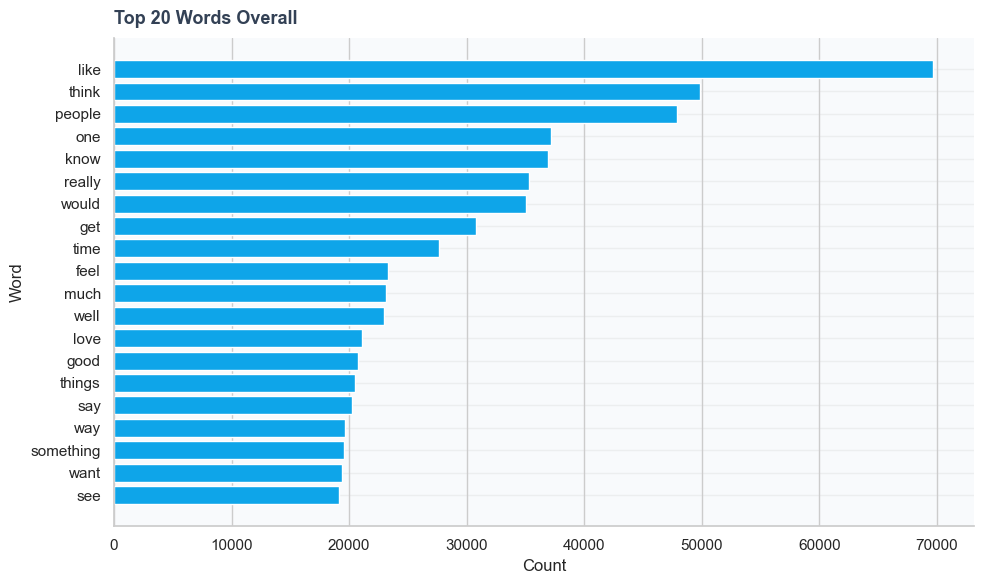

In [32]:
words = Counter(" ".join(df["clean_ns"]).split()).most_common(20)
w_df = pd.DataFrame(words, columns=["word", "count"]).sort_values("count")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(w_df["word"], w_df["count"], color=CHART_COLORS["secondary"])
style_ax(ax, "Top 20 Words Overall", "Count", "Word")
plt.tight_layout()
plt.show()

### 11.1 Top Words by MBTI Type (Top 6 Largest Classes)

To keep plots readable, this section shows top words for the 6 largest MBTI classes by sample size.

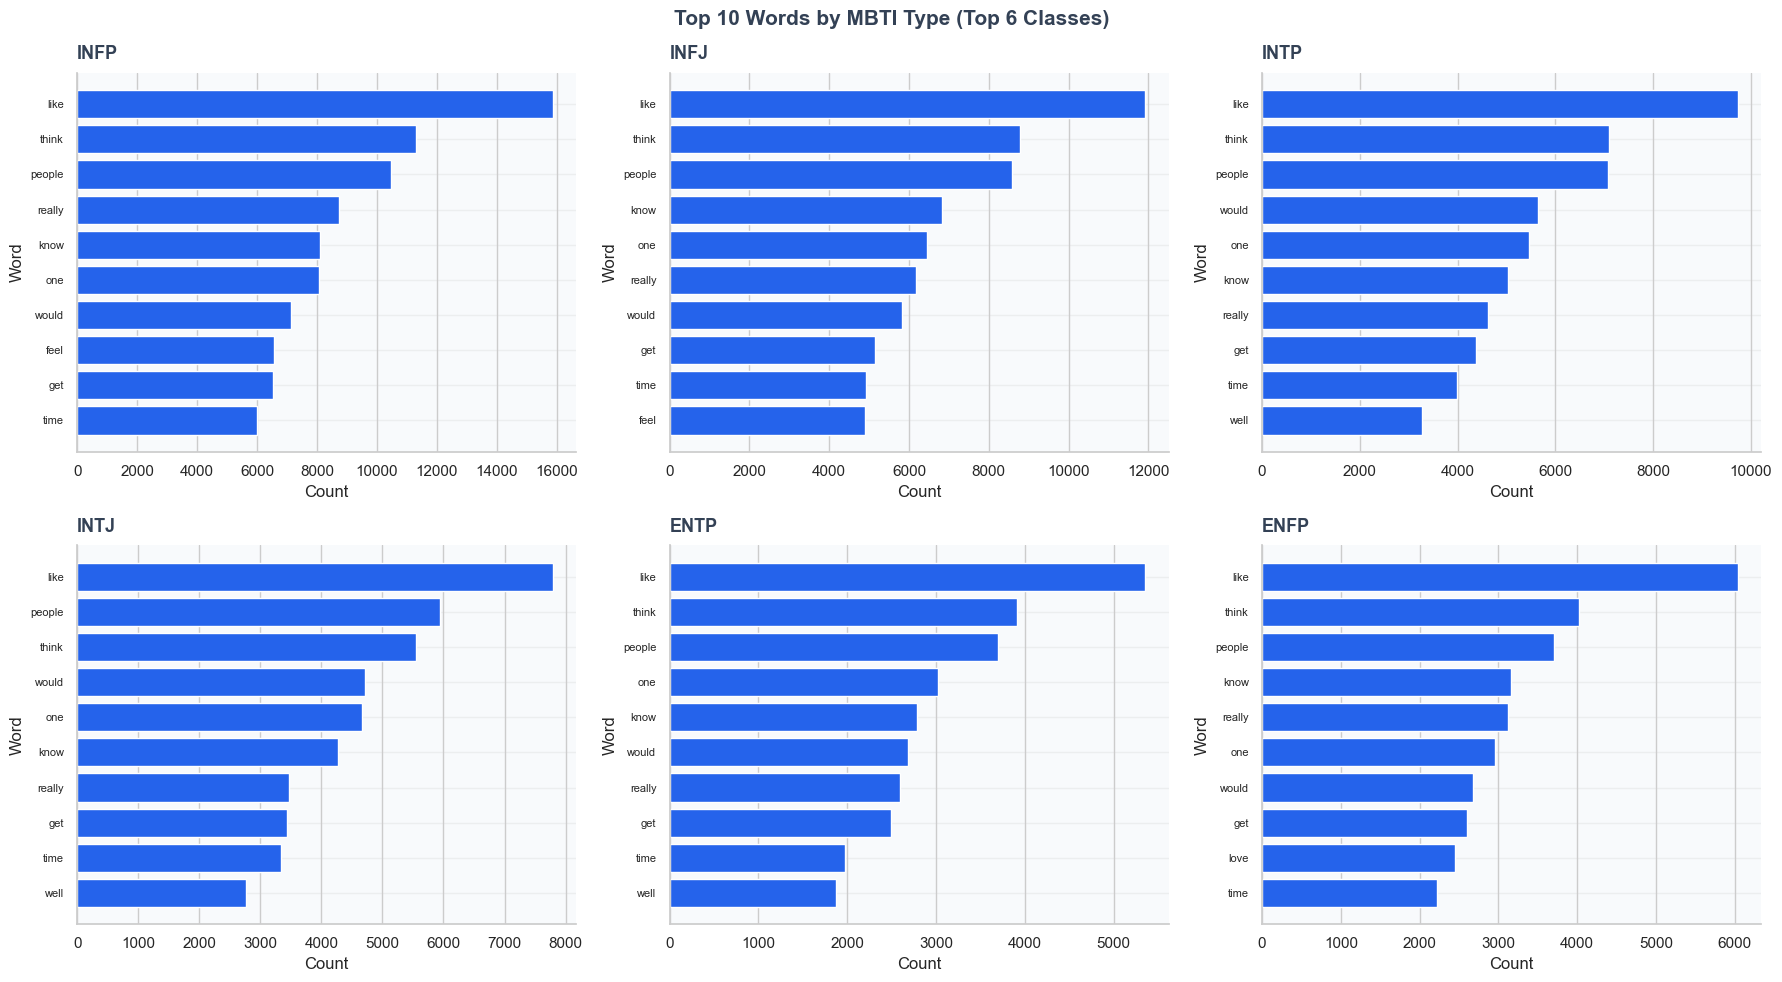

In [40]:
top_types = df["type"].value_counts().head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Top 10 Words by MBTI Type (Top 6 Classes)", fontsize=15, fontweight="bold", color=CHART_COLORS["neutral"])

for ax, mbti_type in zip(axes.flatten(), top_types):
    words = Counter(" ".join(df.loc[df["type"] == mbti_type, "clean_ns_noleak"]).split()).most_common(10)
    w_df = pd.DataFrame(words, columns=["word", "count"]).sort_values("count")
    ax.barh(w_df["word"], w_df["count"], color=CHART_COLORS["primary"])
    style_ax(ax, f"{mbti_type}", "Count", "Word")
    ax.tick_params(axis="y", labelsize=8)

for ax in axes.flatten()[len(top_types):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 12. Top Words by Trait (I vs E)

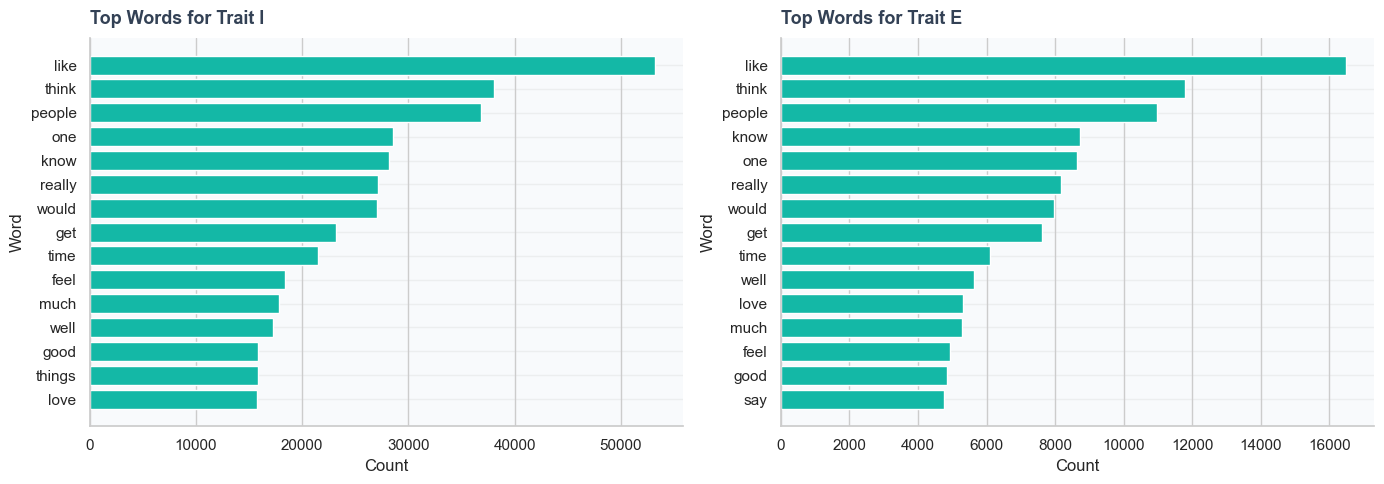

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, trait_value in zip(axes, ["I", "E"]):
    words = Counter(" ".join(df[df["I_E"] == trait_value]["clean_ns"]).split()).most_common(15)
    w_df = pd.DataFrame(words, columns=["word", "count"]).sort_values("count")
    ax.barh(w_df["word"], w_df["count"], color=CHART_COLORS["accent"])
    style_ax(ax, f"Top Words for Trait {trait_value}", "Count", "Word")

plt.tight_layout()
plt.show()

## 13. TF-IDF Top Terms by MBTI Type

This section extracts representative terms per MBTI type using mean TF-IDF scores over documents in each class.

In [35]:
tfidf_vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 1))
X_tfidf = tfidf_vec.fit_transform(df["clean_ns_noleak"]) 
terms = tfidf_vec.get_feature_names_out()

type_indices = {mbti: np.where(df["type"].values == mbti)[0] for mbti in sorted(df["type"].unique())}

tfidf_top_terms = {}
for mbti, idx in type_indices.items():
    mean_scores = np.asarray(X_tfidf[idx].mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[::-1][:10]
    tfidf_top_terms[mbti] = [(terms[i], float(mean_scores[i])) for i in top_idx]

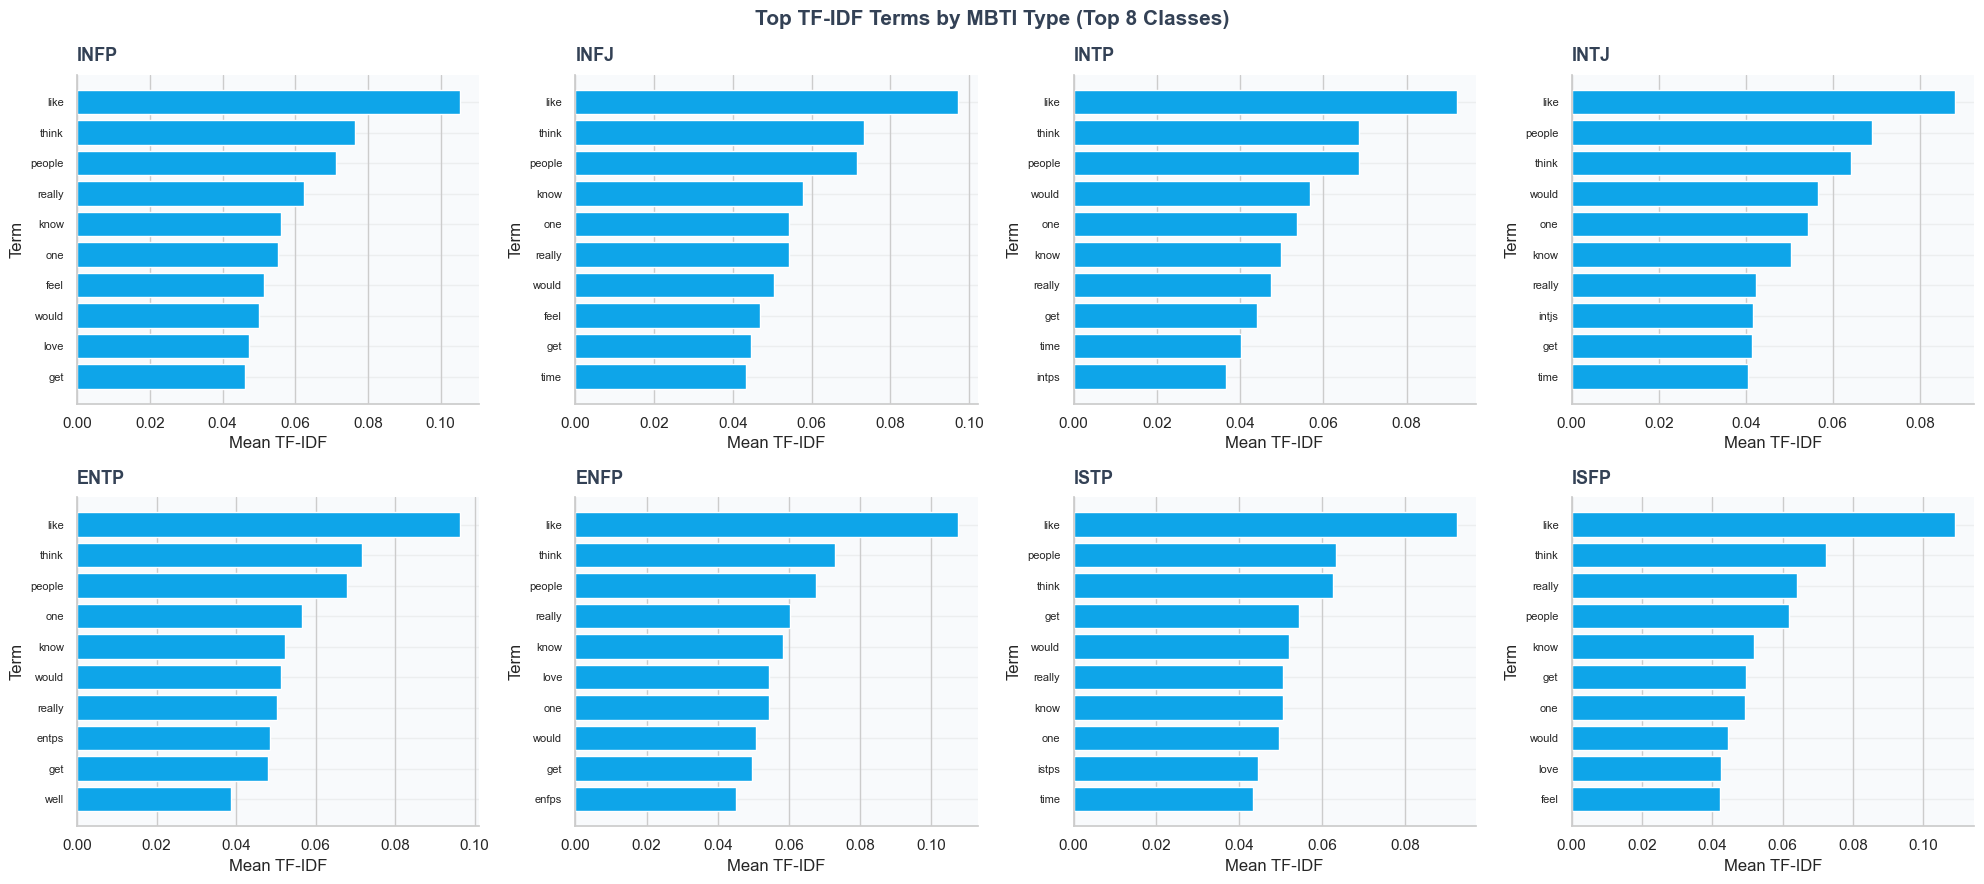

In [36]:
top_types_tfidf = df["type"].value_counts().head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle("Top TF-IDF Terms by MBTI Type (Top 8 Classes)", fontsize=15, fontweight="bold", color=CHART_COLORS["neutral"])

for ax, mbti in zip(axes.flatten(), top_types_tfidf):
    t_df = pd.DataFrame(tfidf_top_terms[mbti], columns=["term", "score"]).sort_values("score")
    ax.barh(t_df["term"], t_df["score"], color=CHART_COLORS["secondary"])
    style_ax(ax, mbti, "Mean TF-IDF", "Term")
    ax.tick_params(axis="y", labelsize=8)

for ax in axes.flatten()[len(top_types_tfidf):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 14. N-gram Analysis (Bigrams)

Analyze frequent two-word phrases overall and by MBTI type to capture context-level patterns beyond single words.

,bigram,count
0,feel like,5645
1,sounds like,2609
2,pretty much,2409
3,high school,2216
4,would say,1997
5,seems like,1904
6,even though,1899
7,would like,1844
8,best friend,1698
9,really like,1570


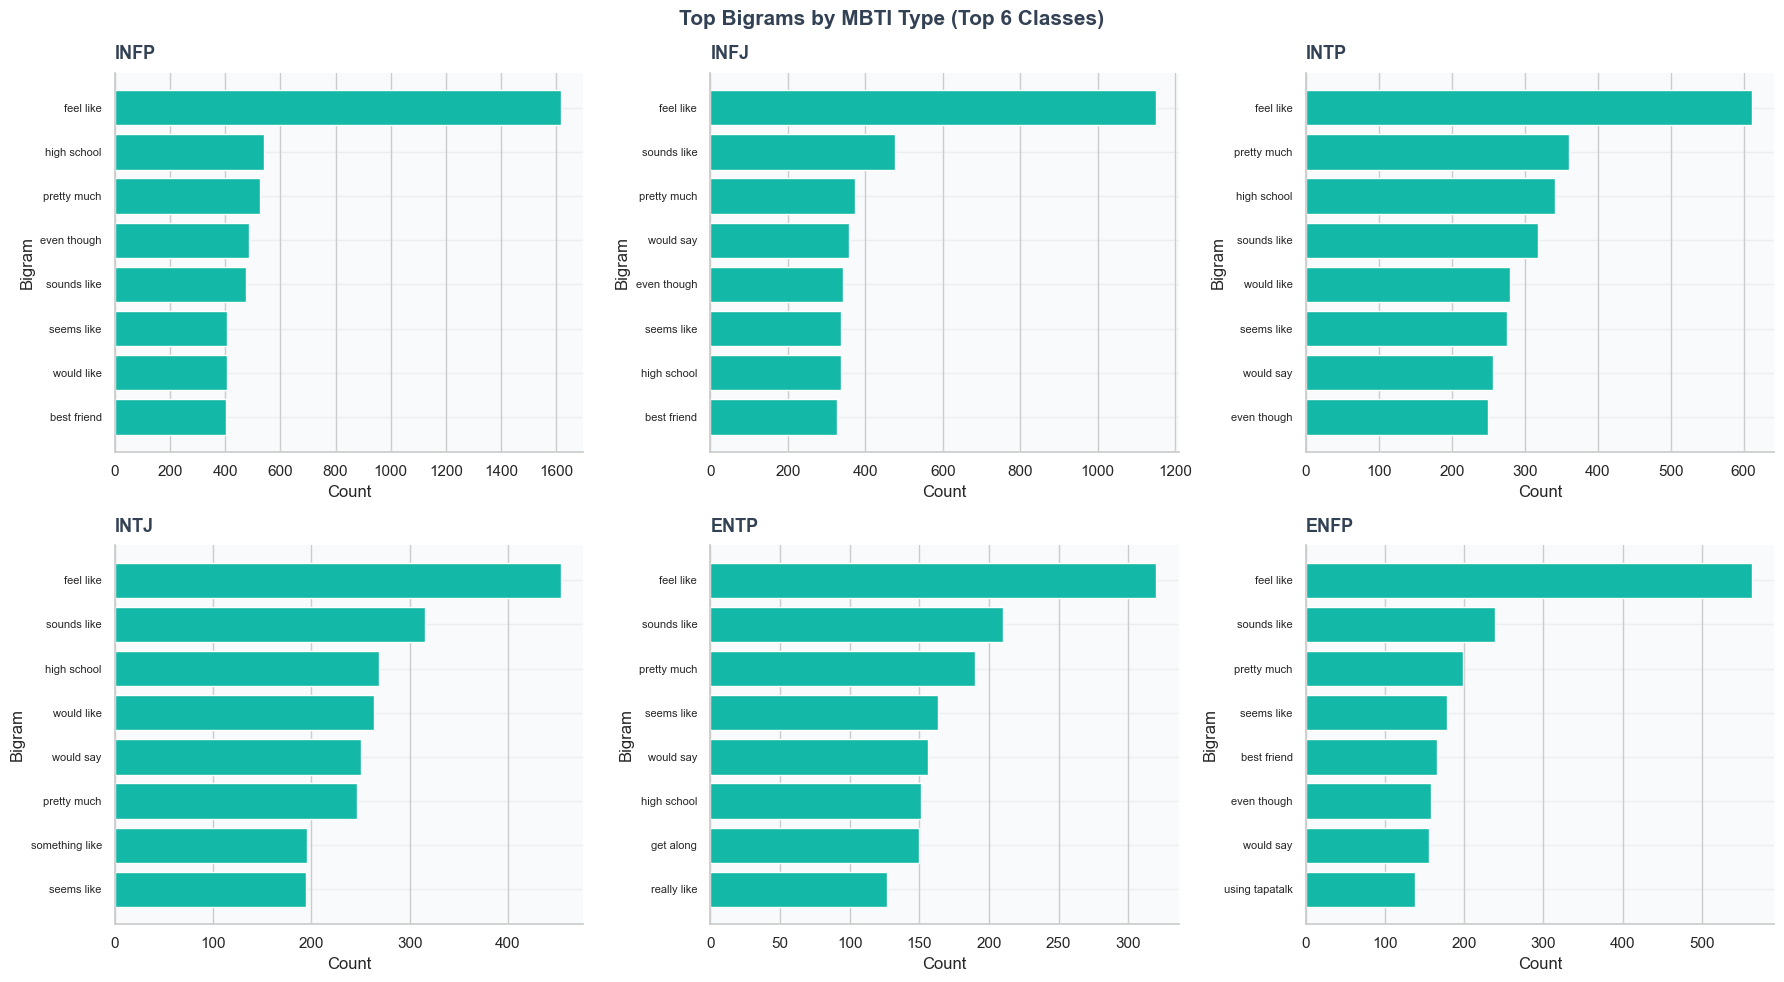

In [39]:
bigram_vec = CountVectorizer(ngram_range=(2, 2), max_features=3000)
X_bigram = bigram_vec.fit_transform(df["clean_ns_noleak"])
bigram_terms = bigram_vec.get_feature_names_out()

overall_bigram_counts = np.asarray(X_bigram.sum(axis=0)).flatten()
overall_top_idx = overall_bigram_counts.argsort()[::-1][:15]
overall_bigram_df = pd.DataFrame(
    {
        "bigram": [bigram_terms[i] for i in overall_top_idx],
        "count": [int(overall_bigram_counts[i]) for i in overall_top_idx],
    }
)

display(overall_bigram_df)

top_types_bigram = df["type"].value_counts().head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Top Bigrams by MBTI Type (Top 6 Classes)", fontsize=15, fontweight="bold", color=CHART_COLORS["neutral"])

for ax, mbti in zip(axes.flatten(), top_types_bigram):
    idx = np.where(df["type"].values == mbti)[0]
    type_counts = np.asarray(X_bigram[idx].sum(axis=0)).flatten()
    top_idx = type_counts.argsort()[::-1][:8]
    b_df = pd.DataFrame(
        {
            "bigram": [bigram_terms[i] for i in top_idx],
            "count": [int(type_counts[i]) for i in top_idx],
        }
    ).sort_values("count")
    ax.barh(b_df["bigram"], b_df["count"], color=CHART_COLORS["accent"])
    style_ax(ax, mbti, "Count", "Bigram")
    ax.tick_params(axis="y", labelsize=8)

for ax in axes.flatten()[len(top_types_bigram):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 15. MBTI Type Similarity Matrix

Compute cosine similarity between MBTI types using type-level mean TF-IDF vectors to identify linguistically close classes.

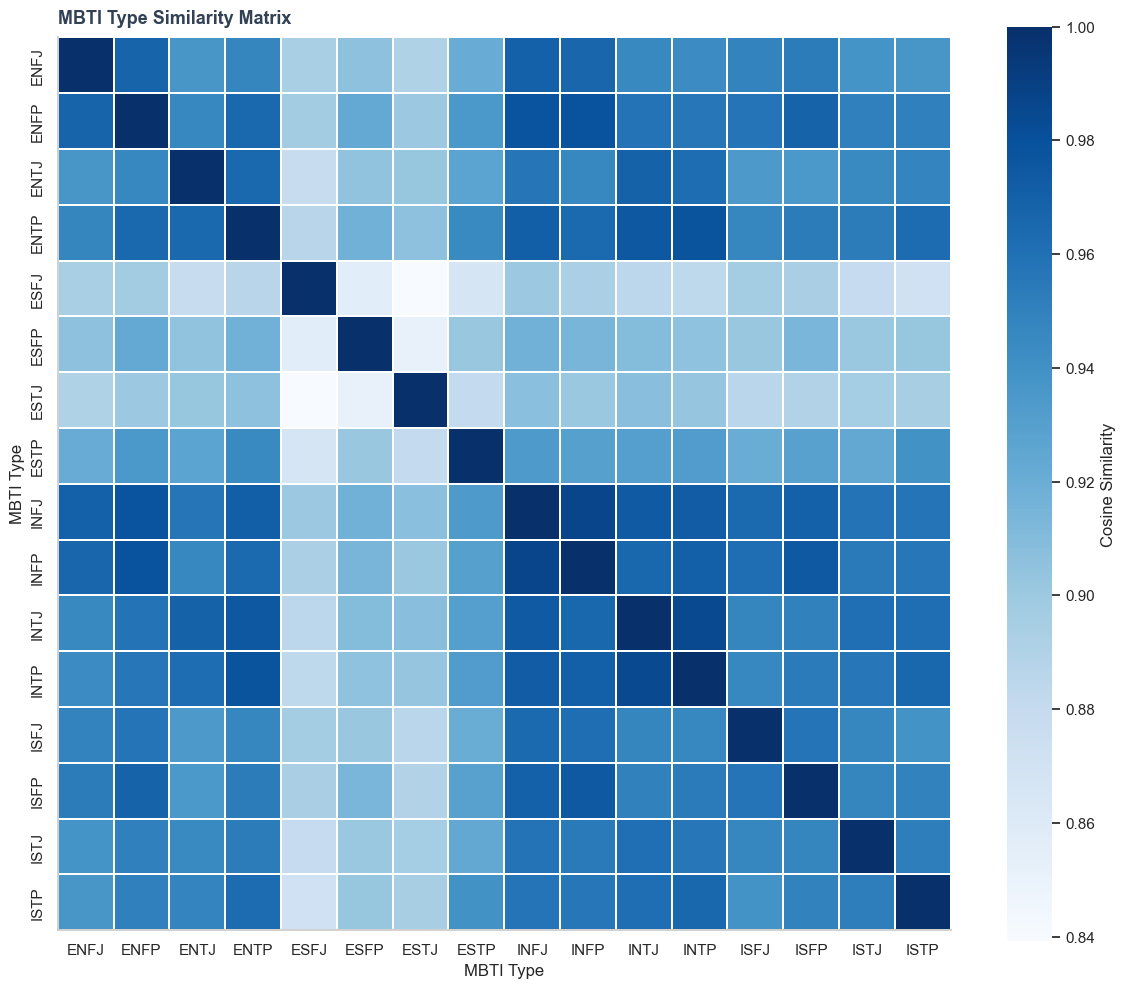

,type_a,type_b,cosine_similarity
0,INFJ,INFP,0.986941
1,INTJ,INTP,0.984342
2,ENFP,INFP,0.978936
3,ENFP,INFJ,0.978463
4,ENTP,INTP,0.978004
5,ENTP,INTJ,0.975343
6,INFP,ISFP,0.974532
7,INFJ,INTJ,0.973733


In [38]:
type_order = sorted(df["type"].unique())

type_centroids = []
for mbti in type_order:
    idx = np.where(df["type"].values == mbti)[0]
    centroid = np.asarray(X_tfidf[idx].mean(axis=0)).flatten()
    type_centroids.append(centroid)

type_centroids = np.vstack(type_centroids)
sim_matrix = cosine_similarity(type_centroids)

sim_df = pd.DataFrame(sim_matrix, index=type_order, columns=type_order)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    sim_df,
    cmap="Blues",
    annot=False,
    square=True,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "Cosine Similarity"},
    ax=ax,
)
style_ax(ax, "MBTI Type Similarity Matrix", "MBTI Type", "MBTI Type")
plt.tight_layout()
plt.show()

pairs = []
for i, t1 in enumerate(type_order):
    for j, t2 in enumerate(type_order):
        if i < j:
            pairs.append((t1, t2, sim_matrix[i, j]))

closest_pairs = sorted(pairs, key=lambda x: x[2], reverse=True)[:8]
closest_pairs_df = pd.DataFrame(closest_pairs, columns=["type_a", "type_b", "cosine_similarity"])
display(closest_pairs_df)

## 16. Text Statistics

In [23]:
print("avg words",df["word_count"].mean())
print("avg chars",df["char_count"].mean())
print("avg posts",df["num_posts"].mean())

avg words 1226.2414985590779
avg chars 7234.98962536023
avg posts 48.74293948126801


## 17. Sample Posts

In [24]:
df.sample(3)[["type","posts"]]

,type,posts
2581,ISFP,"'I'm kind on the outside, that's for sure. I n..."
8310,INFJ,'He wants to know if allowing himself to love ...
6674,ENTJ,'I did the same thing when I had a major life ...


### 17.1 Consolidated Dataset Metrics

In [4]:
type_counts = df["type"].value_counts()
imbalance_ratio = round(type_counts.max() / type_counts.min(), 2)

overview_metrics = pd.DataFrame(
    {
        "metric": [
            "Number of records",
            "Number of MBTI classes",
            "Largest class size",
            "Smallest class size",
            "Class imbalance ratio (max/min)",
        ],
        "value": [
            int(len(df)),
            int(type_counts.shape[0]),
            int(type_counts.max()),
            int(type_counts.min()),
            float(imbalance_ratio),
        ],
    }
)

display(overview_metrics)

,metric,value
0,Number of records,8675.00
1,Number of MBTI classes,16.00
2,Largest class size,1832.00
3,Smallest class size,39.00
4,Class imbalance ratio (max/min),46.97


## 18. Key Findings and Potential Issues

### Key Findings
1. The MBTI label distribution is strongly imbalanced, so macro-level metrics are required for fair evaluation.
2. Word/character/post-length distributions vary considerably, implying different writing intensity across users.
3. Stop-word and vocabulary analyses show high lexical overlap, but each MBTI class still has distinctive top terms.
4. TF-IDF and bigram analyses reveal class-specific signals while also exposing close linguistic groups.
5. Similarity matrix indicates several MBTI pairs are semantically close, suggesting harder decision boundaries.

### Potential Issues
- Class imbalance may bias predictions toward frequent MBTI types.
- Informal text noise (URLs, punctuation artifacts, separators) can inflate sparse vocabulary.